# Análisis Exploratorio de Datos (EDA)
## Seguridad y Convivencia en Colombia · 2018–2024

---

| Campo | Detalle |
|---|---|
| **Fuente** | Policía Nacional de Colombia — Datos Abiertos |
| **Modelo** | Estrella en DuckDB (`datos/db/seguridad_convivencia.duckdb`) |
| **Período** | 2018 – 2024 (7 años) |
| **Registros** | ~3 412 455 hechos delictivos |
| **Cobertura** | 33 departamentos · 18 tipos de delito |
| **Versión ETL** | v2 — corrección ingesta 2021 delitos sexuales |

### Objetivos

1. Validar la integridad del modelo estrella tras el pipeline ETL.
2. Identificar tendencias temporales, departamentales y por tipo de delito.
3. Documentar los ajustes de calidad de datos aplicados en la ingesta.

> **Reproducibilidad:** Para regenerar la BD ejecutar primero  
> `python -m src.transformacion.pipeline` y `python -m src.transformacion.modelo_estrella`.

## Tabla de Contenidos

| # | Sección |
|---|---------|
| 1 | [Inventario del Modelo Estrella](#1-inventario-del-modelo-estrella) |
| 2 | [Calidad de Datos e Incidencias ETL](#2-calidad-de-datos-e-incidencias-etl) |
| 3 | [Evolución Anual de Delitos](#3-evolución-anual-de-delitos-20182024) |
| 4 | [Composición por Tipo de Delito](#4-composición-por-tipo-de-delito) |
| 5 | [Análisis Departamental](#5-análisis-departamental) |
| 6 | [Mapa de Calor: Tipo de Delito × Año](#6-mapa-de-calor-tipo-de-delito--año) |
| 7 | [Víctimas por Género](#7-víctimas-por-género) |
| 8 | [Homicidios Intencionales — Series de Tiempo](#8-homicidios-intencionales--series-de-tiempo) |

In [1]:
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Conexión ──────────────────────────────────────────────────────────────────
REPO_ROOT = Path("..").resolve()
DB_PATH   = REPO_ROOT / "datos" / "db" / "seguridad_convivencia.duckdb"

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"BD no encontrada: {DB_PATH}\n"
        "Ejecuta primero:\n"
        "  python -m src.transformacion.pipeline\n"
        "  python -m src.transformacion.modelo_estrella"
    )

con = duckdb.connect(str(DB_PATH), read_only=True)
print(f"✓ Conectado a: {DB_PATH.name}")

# ── Paleta institucional ───────────────────────────────────────────────────────
AZUL   = "#002D72"
DORADO = "#FDB813"
ROJO   = "#C0392B"

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi":          120,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.titleweight":    "bold",
    "axes.titlesize":      13,
})

# ── Helpers ───────────────────────────────────────────────────────────────────
_DEPTO_DISPLAY = {
    "BOGOTA D.C. (DISTRITO CAPITAL)": "Bogotá D.C.",
    "NARINO":     "Nariño",        "GUAJIRA":    "La Guajira",
    "SAN ANDRES": "San Andrés",    "VALLE":      "Valle del Cauca",
    "ATLANTICO":  "Atlántico",     "BOLIVAR":    "Bolívar",
    "BOYACA":     "Boyacá",        "CAQUETA":    "Caquetá",
    "VAUPES":     "Vaupés",        "CHOCO":      "Chocó",
    "CORDOBA":    "Córdoba",       "GUAINIA":    "Guainía",
    "QUINDIO":    "Quindío",
}

def fmt_depto(nombre: str) -> str:
    """Convierte nombre de departamento de la BD al nombre oficial con tildes."""
    return _DEPTO_DISPLAY.get(str(nombre).upper().strip(), str(nombre).title())

def fmt_num(n: float) -> str:
    """Formatea números grandes con sufijo M / K."""
    if n >= 1e6: return f"{n/1e6:.2f}M"
    if n >= 1e3: return f"{n/1e3:.1f}K"
    return str(int(n))

✓ Conectado a: seguridad_convivencia.duckdb


## 1. Inventario del Modelo Estrella

El pipeline ETL consolida los registros de la Policía Nacional en un **modelo estrella** almacenado en DuckDB. La tabla central `fact_delitos` referencia cuatro dimensiones: fecha, ubicación geográfica, tipo de delito y perfil de la víctima.

In [2]:
TABLAS = {
    "fact_delitos":  "Tabla de hechos — un registro por evento delictivo",
    "dim_fecha":     "Años disponibles en el modelo",
    "dim_ubicacion": "Combinaciones departamento / municipio / código DANE",
    "dim_delito":    "Tipos de delito catalogados",
    "dim_arma":      "Armas o medios empleados",
    "dim_victima":   "Combinaciones género / grupo etario",
}

print(f"{'Tabla':<25} {'Filas':>12}   Descripción")
print("─" * 78)
for tabla, desc in TABLAS.items():
    n = con.execute(f"SELECT COUNT(*) FROM {tabla}").fetchone()[0]
    print(f"{tabla:<25} {n:>12,}   {desc}")

Tabla                            Filas   Descripción
──────────────────────────────────────────────────────────────────────────────
fact_delitos                 3,412,455   Tabla de hechos — un registro por evento delictivo
dim_fecha                        2,557   Años disponibles en el modelo
dim_ubicacion                    1,108   Combinaciones departamento / municipio / código DANE
dim_delito                          18   Tipos de delito catalogados
dim_arma                            62   Armas o medios empleados
dim_victima                         19   Combinaciones género / grupo etario


## 2. Calidad de Datos e Incidencias ETL

El pipeline ETL identificó y corrigió automáticamente los siguientes problemas estructurales en los archivos fuente de la Policía Nacional:

| Archivo | Problema detectado | Solución aplicada |
|---|---|---|
| `delitos_sexuales/2021.xls` | Columnas `DEPARTAMENTO` y `ARMAS_MEDIOS` publicadas en orden invertido por la Policía Nacional | Detección automática: si > 50 % de los valores en `DEPARTAMENTO` contienen vocabulario de armas, se intercambian las columnas |

> **Criterio de detección:** Los nombres de departamento nunca contienen términos como *ARMA CONTUNDENTE*, *SIN EMPLEO DE ARMAS* o *ESCOPOLAMINA*. Si más del 50 % de los valores en `DEPARTAMENTO` corresponden a ese vocabulario, la inversión se aplica y queda registrada en el log del pipeline.

La celda siguiente verifica que la corrección fue exitosa consultando directamente el modelo estrella resultante.

In [3]:
# ── Verificación 1: DEPARTAMENTO no debe contener vocabulario de armas ────────
_ARMAS_KW = {"ARMA", "CONTUNDENTE", "ESCOPOLAMINA", "SIN EMPLEO", "CINTAS", "ESPOSAS"}

df_deptos = con.execute("SELECT DISTINCT departamento FROM dim_ubicacion ORDER BY 1").df()
falsos = df_deptos["departamento"].apply(
    lambda x: any(k in x.upper() for k in _ARMAS_KW)
)
print(f"Departamentos con términos de arma (esperado 0): {falsos.sum()}")
print(f"Total departamentos únicos en el modelo        : {len(df_deptos)}")

# ── Verificación 2: delitos sexuales 2021 — serie coherente post-corrección ───
df_sex = con.execute("""
    SELECT d.anio, SUM(f.cantidad) AS total
    FROM fact_delitos f
    JOIN dim_fecha  d   USING (fecha_key)
    JOIN dim_delito del USING (delito_key)
    WHERE del.tipo_delito = 'DELITOS SEXUALES'
    GROUP BY 1 ORDER BY 1
""").df()

df_sex.columns = ["Año", "Total delitos sexuales"]
df_sex["Total delitos sexuales"] = df_sex["Total delitos sexuales"].apply(lambda x: f"{int(x):,}")
print("\nDelitos sexuales por año (2021 ya corregido):")
print(df_sex.to_string(index=False))

Departamentos con términos de arma (esperado 0): 0
Total departamentos únicos en el modelo        : 33

Delitos sexuales por año (2021 ya corregido):
 Año Total delitos sexuales
2018                 36,791
2019                 38,204
2020                 30,924
2021                 34,733
2022                 27,666
2023                 28,053
2024                 31,474


## 3. Evolución Anual de Delitos (2018–2024)

Se contabilizan todos los hechos registrados por la Policía Nacional agrupados por año. El acumulado del período supera los **3,4 millones** de eventos. La barra de 2020 (rojo) refleja el efecto de las restricciones por COVID-19.

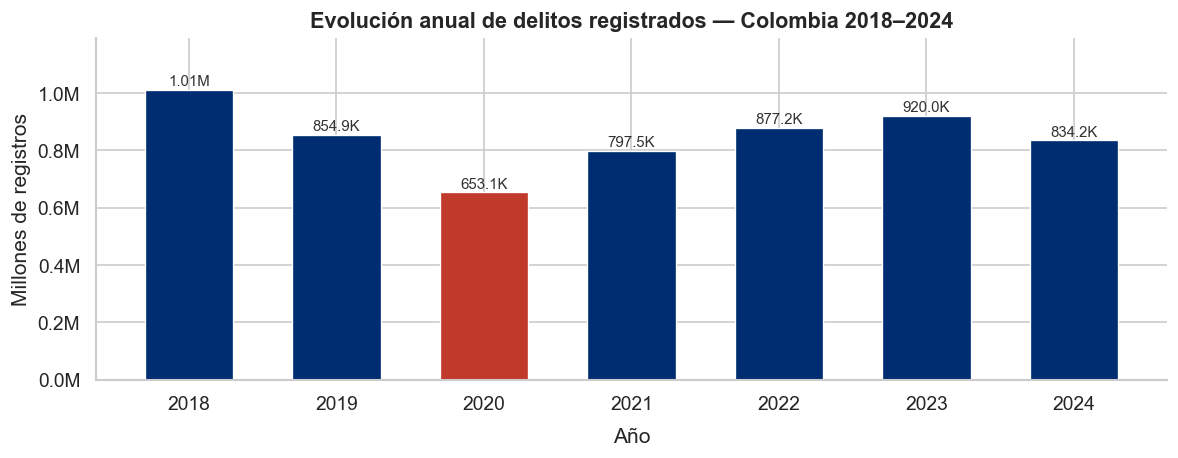

,Total delitos,Variación %
Año,,
2018,"1,011,103",NaN
2019,"854,922",-15.4
2020,"653,072",-23.6
2021,"797,472",22.1
2022,"877,208",10.0
2023,"920,010",4.9
2024,"834,172",-9.3


In [4]:
df_anio = con.execute("""
    SELECT d.anio, SUM(f.cantidad) AS total
    FROM fact_delitos f
    JOIN dim_fecha d USING (fecha_key)
    GROUP BY 1 ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(10, 4))
colores = [ROJO if y == 2020 else AZUL for y in df_anio["anio"]]
bars = ax.bar(df_anio["anio"], df_anio["total"] / 1e6,
              color=colores, edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, df_anio["total"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            fmt_num(val), ha="center", va="bottom", fontsize=9, color="#333")

ax.set_xlabel("Año", labelpad=8)
ax.set_ylabel("Millones de registros")
ax.set_title("Evolución anual de delitos registrados — Colombia 2018–2024")
ax.set_xticks(df_anio["anio"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax.set_ylim(0, df_anio["total"].max() / 1e6 * 1.18)
plt.tight_layout()
plt.show()

# Tabla resumen con variación interanual
df_tabla = df_anio.copy()
df_tabla["variacion_%"] = df_tabla["total"].pct_change().mul(100).round(1)
df_tabla.columns = ["Año", "Total delitos", "Variación %"]
df_tabla["Total delitos"] = df_tabla["Total delitos"].apply(lambda x: f"{int(x):,}")
df_tabla.set_index("Año")

> **2020 — Efecto COVID-19:** La caída observada en 2020 responde a las restricciones de movilidad decretadas durante la pandemia, que redujeron significativamente la actividad delictiva en espacios públicos —especialmente hurtos y lesiones personales—. **No implica una mejora estructural de la seguridad pública.**

## 4. Composición por Tipo de Delito

Se desagregan los **18 tipos** de delito catalogados para identificar los de mayor volumen. Históricamente, las *lesiones personales* y la *violencia intrafamiliar* representan más del 40 % del total registrado.

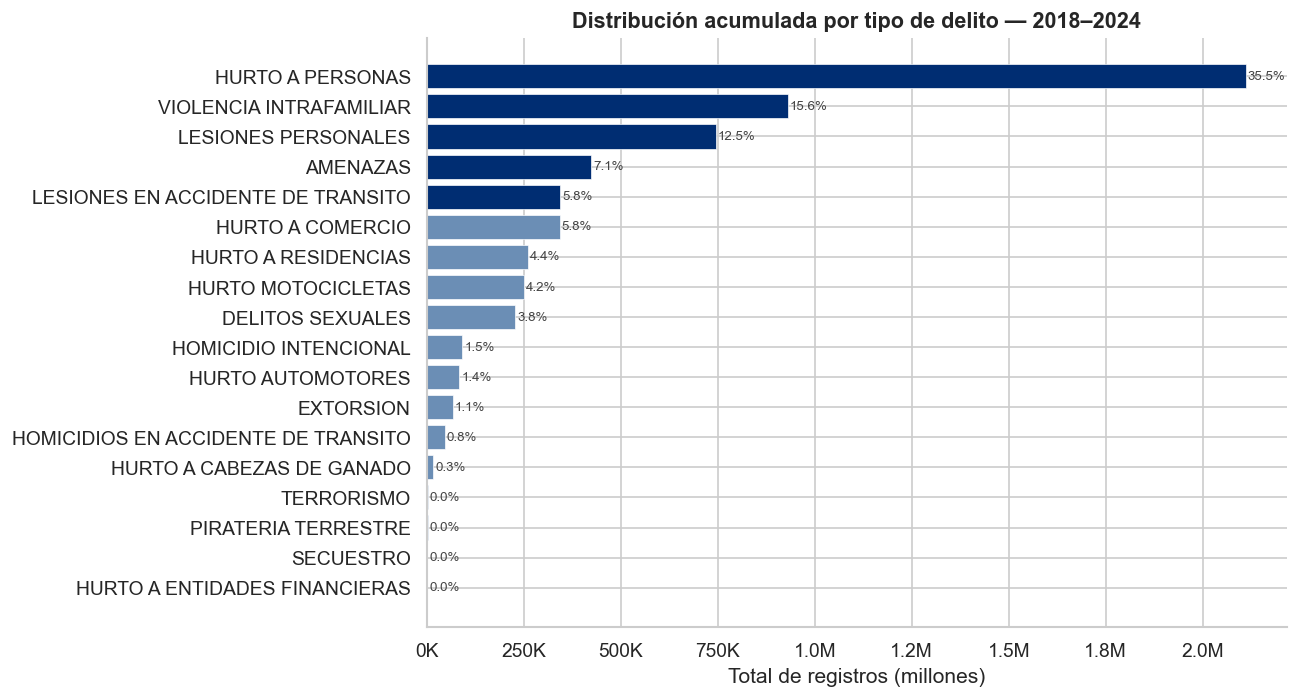

,Total,% del total
Tipo de delito,,
HURTO A PERSONAS,"2,110,710",35.5
VIOLENCIA INTRAFAMILIAR,"930,647",15.6
LESIONES PERSONALES,"745,763",12.5
AMENAZAS,"423,304",7.1
LESIONES EN ACCIDENTE DE TRANSITO,"344,175",5.8
HURTO A COMERCIO,"342,458",5.8
HURTO A RESIDENCIAS,"260,558",4.4
HURTO MOTOCICLETAS,"249,468",4.2
DELITOS SEXUALES,"227,845",3.8


In [5]:
df_delito = con.execute("""
    SELECT del.tipo_delito, SUM(f.cantidad) AS total
    FROM fact_delitos f
    JOIN dim_delito del USING (delito_key)
    GROUP BY 1 ORDER BY 2 DESC
""").df()

df_delito["pct"] = (df_delito["total"] / df_delito["total"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(11, 6))
colores = [AZUL if i < 5 else "#6B8EB5" for i in range(len(df_delito))]
bars = ax.barh(df_delito["tipo_delito"], df_delito["total"] / 1e6,
               color=colores, edgecolor="white", linewidth=0.4)

for bar, pct in zip(bars, df_delito["pct"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=8, color="#444")

ax.set_xlabel("Total de registros (millones)")
ax.set_title("Distribución acumulada por tipo de delito — 2018–2024")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.1f}M" if x >= 1 else f"{x*1000:.0f}K"))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

df_delito[["tipo_delito", "total", "pct"]].rename(
    columns={"tipo_delito": "Tipo de delito", "total": "Total", "pct": "% del total"}
).assign(Total=lambda df: df["Total"].apply(lambda x: f"{int(x):,}")
).set_index("Tipo de delito")

## 5. Análisis Departamental

Ranking de los **10 departamentos** con mayor volumen acumulado de delitos (2018–2024). Antioquia, Valle del Cauca y Bogotá D.C. concentran históricamente más del 40 % del total nacional, en parte por ser los de mayor densidad poblacional.

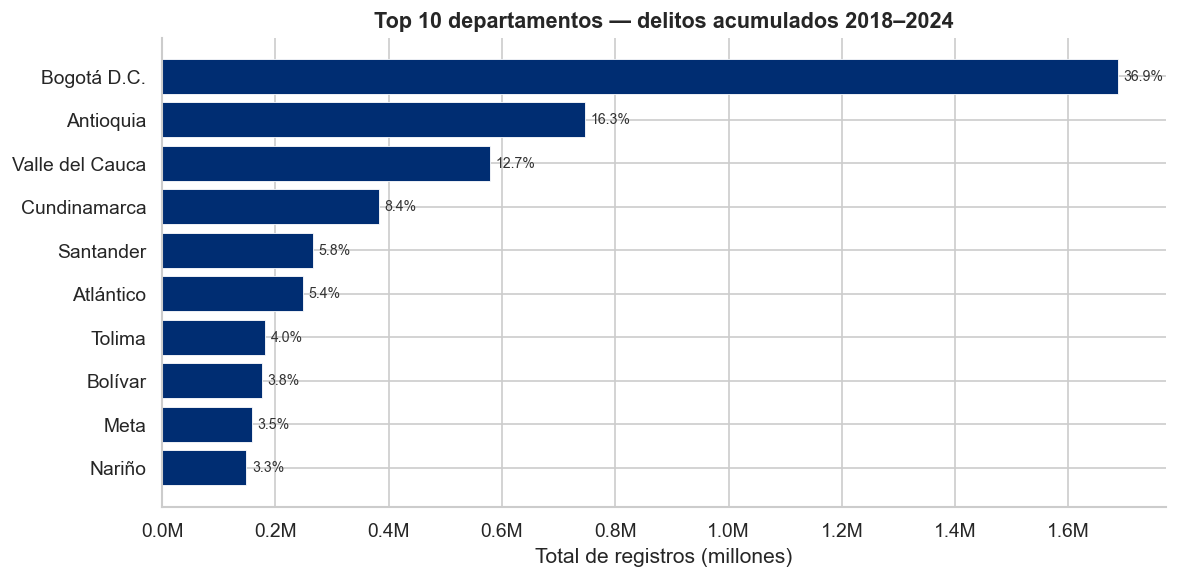

,Total delitos,% sobre Top-10
Departamento,,
Bogotá D.C.,"1,687,197",36.9
Antioquia,"746,873",16.3
Valle del Cauca,"579,371",12.7
Cundinamarca,"382,572",8.4
Santander,"266,056",5.8
Atlántico,"247,928",5.4
Tolima,"181,419",4.0
Bolívar,"175,969",3.8
Meta,"158,584",3.5


In [6]:
df_depto = con.execute("""
    SELECT
        CASE
            WHEN u.departamento = 'CUNDINAMARCA' AND u.municipio = 'BOGOTA D.C.'
                THEN 'BOGOTA D.C. (DISTRITO CAPITAL)'
            ELSE u.departamento
        END AS departamento,
        SUM(f.cantidad) AS total
    FROM fact_delitos f
    JOIN dim_ubicacion u USING (ubicacion_key)
    GROUP BY 1 ORDER BY 2 DESC
    LIMIT 10
""").df()

df_depto["nombre"] = df_depto["departamento"].apply(fmt_depto)
total_top10 = df_depto["total"].sum()
df_depto["pct"] = (df_depto["total"] / total_top10 * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_depto["nombre"], df_depto["total"] / 1e6,
               color=AZUL, edgecolor="white", linewidth=0.5)

for bar, pct in zip(bars, df_depto["pct"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=8.5, color="#333")

ax.set_xlabel("Total de registros (millones)")
ax.set_title("Top 10 departamentos — delitos acumulados 2018–2024")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

df_depto[["nombre", "total", "pct"]].rename(
    columns={"nombre": "Departamento", "total": "Total delitos", "pct": "% sobre Top-10"}
).assign(**{"Total delitos": lambda df: df["Total delitos"].apply(lambda x: f"{int(x):,}")}
).set_index("Departamento")

## 6. Mapa de Calor: Tipo de Delito × Año

La matriz muestra el volumen de cada categoría delictiva por año (**miles de casos**). Las celdas más oscuras indican mayor concentración. Permite identificar de un vistazo qué tipos de delito aumentaron o disminuyeron en el tiempo.

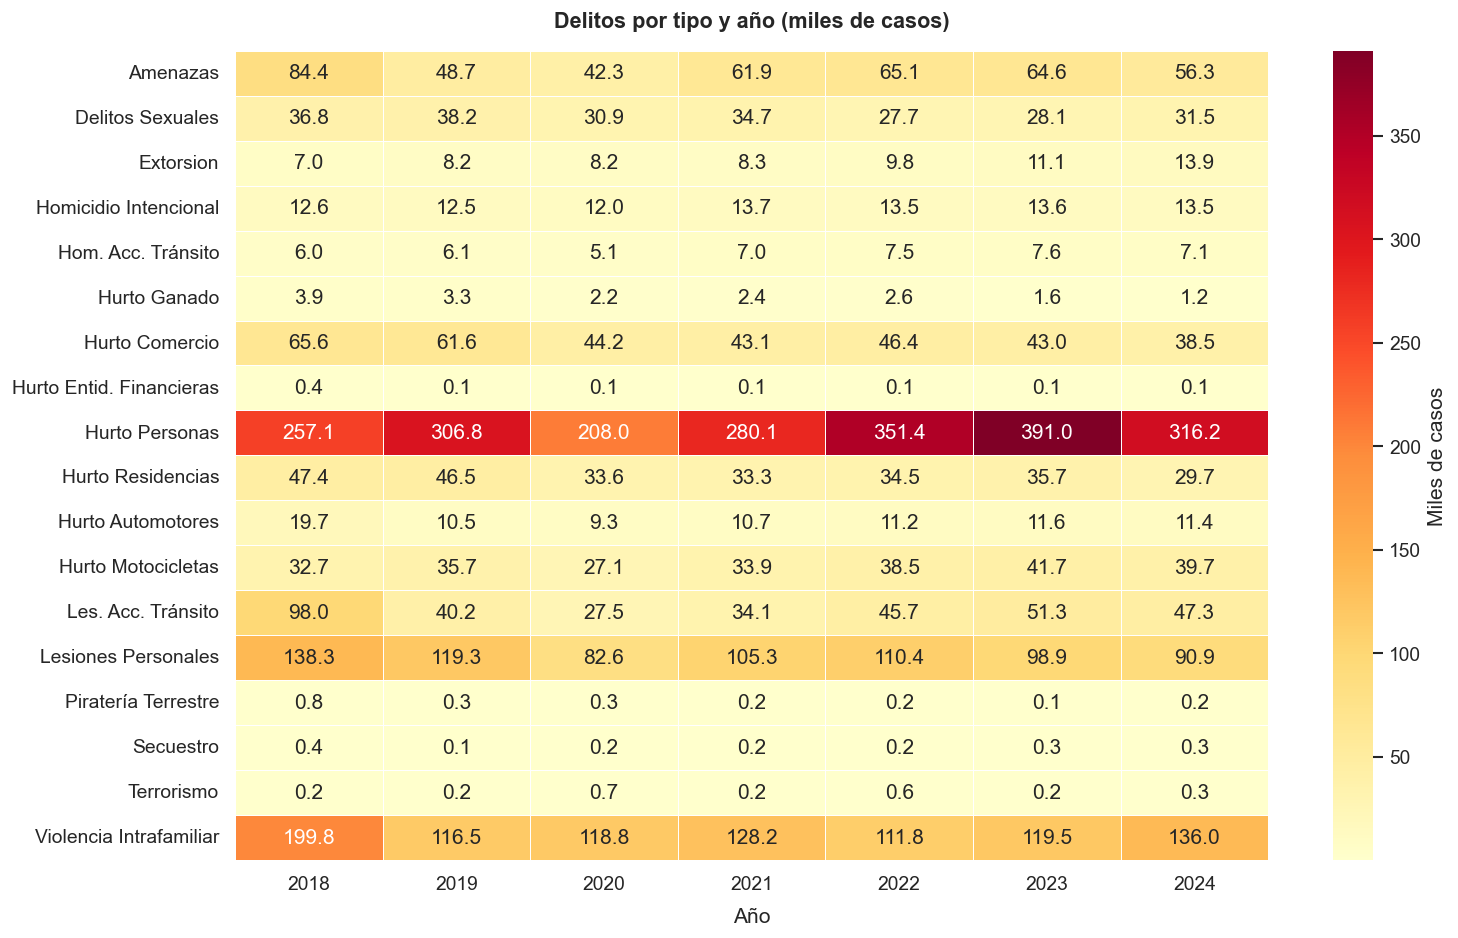

In [7]:
df_heat = con.execute("""
    SELECT d.anio, del.tipo_delito, SUM(f.cantidad) AS total
    FROM fact_delitos f
    JOIN dim_fecha  d   USING (fecha_key)
    JOIN dim_delito del USING (delito_key)
    GROUP BY 1, 2
""").df()

pivot = df_heat.pivot(index="tipo_delito", columns="anio", values="total").fillna(0)
pivot_k = (pivot / 1_000).round(1)   # valores en miles para legibilidad

# Etiquetas abreviadas del eje Y
ABREV = {
    "HOMICIDIOS EN ACCIDENTE DE TRANSITO": "Hom. Acc. Tránsito",
    "LESIONES EN ACCIDENTE DE TRANSITO":   "Les. Acc. Tránsito",
    "VIOLENCIA INTRAFAMILIAR":             "Violencia Intrafamiliar",
    "HURTO A CABEZAS DE GANADO":           "Hurto Ganado",
    "HURTO A ENTIDADES FINANCIERAS":       "Hurto Entid. Financieras",
    "HURTO A RESIDENCIAS":                 "Hurto Residencias",
    "HURTO A PERSONAS":                    "Hurto Personas",
    "HURTO A COMERCIO":                    "Hurto Comercio",
    "HURTO AUTOMOTORES":                   "Hurto Automotores",
    "HURTO MOTOCICLETAS":                  "Hurto Motocicletas",
    "LESIONES PERSONALES":                 "Lesiones Personales",
    "HOMICIDIO INTENCIONAL":               "Homicidio Intencional",
    "DELITOS SEXUALES":                    "Delitos Sexuales",
    "PIRATERIA TERRESTRE":                 "Piratería Terrestre",
}
pivot_k.index = [ABREV.get(i, i.title()) for i in pivot_k.index]

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(
    pivot_k, annot=True, fmt=".1f", linewidths=0.4,
    cmap="YlOrRd", ax=ax,
    cbar_kws={"label": "Miles de casos"},
)
ax.set_title("Delitos por tipo y año (miles de casos)", pad=14)
ax.set_xlabel("Año", labelpad=8)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 7. Víctimas por Género

La desagregación por género permite identificar patrones de victimización diferencial. Los hombres concentran la mayoría de los delitos patrimoniales y violentos; las mujeres presentan mayor proporción en violencia intrafamiliar y delitos sexuales.

In [ ]:
df_gen = con.execute("""
    SELECT v.genero, SUM(f.cantidad) AS total
    FROM fact_delitos f
    JOIN dim_victima v USING (victima_key)
    GROUP BY 1 ORDER BY 2 DESC
""").df()

df_gen["pct"] = (df_gen["total"] / df_gen["total"].sum() * 100).round(1)

PALETTE_GEN = [AZUL, ROJO, "#95A5A6", "#F39C12", "#8E44AD"]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(df_gen["genero"], df_gen["total"] / 1e6,
               color=PALETTE_GEN[:len(df_gen)], edgecolor="white")

for bar, row in zip(bars, df_gen.itertuples()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{row.pct:.1f}%  ({fmt_num(row.total)})",
            va="center", fontsize=8.5, color="#333")

ax.set_xlabel("Registros (millones)")
ax.set_title("Distribución de víctimas por género — 2018–2024")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

df_gen[["genero", "total", "pct"]].rename(
    columns={"genero": "Género", "total": "Total registros", "pct": "%"}
).assign(**{"Total registros": lambda df: df["Total registros"].apply(lambda x: f"{int(x):,}")}
).set_index("Género")

## 8. Homicidios Intencionales — Series de Tiempo

Evolución de homicidios intencionales en los **8 departamentos de mayor incidencia** (2018–2024). Antioquia y Valle del Cauca mantienen los volúmenes más altos, aunque ambos muestran tendencias decrecientes sostenidas desde 2019.

In [ ]:
df_hom = con.execute("""
    SELECT d.anio,
           CASE
               WHEN u.departamento = 'CUNDINAMARCA' AND u.municipio = 'BOGOTA D.C.'
                   THEN 'BOGOTA D.C. (DISTRITO CAPITAL)'
               ELSE u.departamento
           END AS departamento,
           SUM(f.cantidad) AS total
    FROM fact_delitos f
    JOIN dim_fecha     d   USING (fecha_key)
    JOIN dim_ubicacion u   USING (ubicacion_key)
    JOIN dim_delito    del USING (delito_key)
    WHERE del.tipo_delito = 'HOMICIDIO INTENCIONAL'
    GROUP BY 1, 2
""").df()

top8 = df_hom.groupby("departamento")["total"].sum().nlargest(8).index
df_plot = df_hom[df_hom["departamento"].isin(top8)].copy()
df_plot["nombre"] = df_plot["departamento"].apply(fmt_depto)

PALETTE_HOM = [AZUL, ROJO, "#27AE60", "#F39C12", "#8E44AD",
               "#16A085", "#D35400", "#2C3E50"]

fig, ax = plt.subplots(figsize=(12, 5))
for (nombre, grp), color in zip(df_plot.groupby("nombre"), PALETTE_HOM):
    ax.plot(grp["anio"], grp["total"], marker="o", label=nombre,
            color=color, linewidth=2, markersize=5)

ax.set_xlabel("Año", labelpad=8)
ax.set_ylabel("Homicidios registrados")
ax.set_title("Homicidios intencionales — top 8 departamentos · 2018–2024")
ax.set_xticks(sorted(df_plot["anio"].unique()))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8.5, frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
con.close()
print("✓ Conexión cerrada. Notebook ejecutado correctamente.")